# 序列

**Q**: 解释术语
- 序列和集合

**Q**: 回答问题
- 序列问题分为哪两种

**Q**: 结合行文
- 从何种数据类型角度切入？
- 目前问题的定义是什么？

## 数据生成

**Q**: 生成的数据维度是？形状是？

**Q**: 该形状如何体现出序列？

In [37]:
# 引入

# 数据生成
from data_generation.square_sequences import generate_sequences
# 绘图函数
from plots.chapter8 import *

# 科学计算
import numpy as np

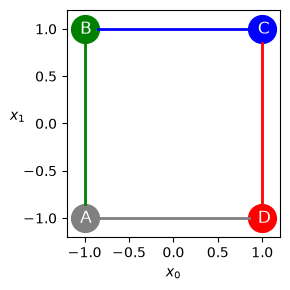

In [38]:
# 可视化: 数据形状
fig = counter_vs_clock(draw_arrows=False)

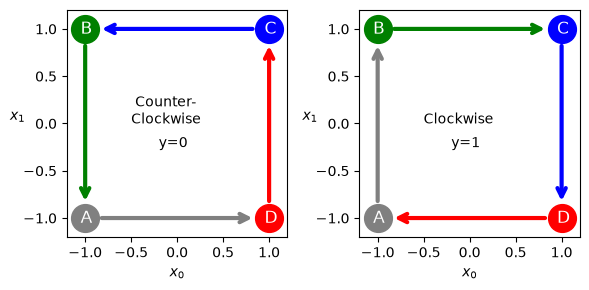

In [39]:
# 可视化: 形状与序列顺序
fig = counter_vs_clock()

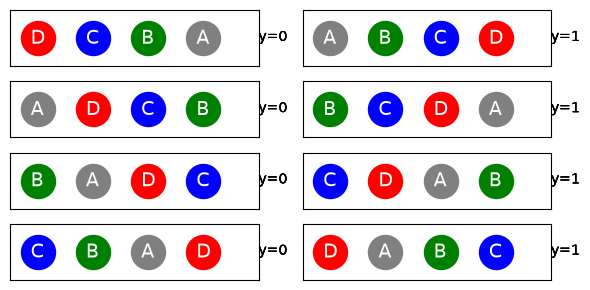

In [40]:
# 可视化: 所有可能的顺序
fig = plot_sequences()

(128, 4, 2) (128,)
[[ 1.03487506  0.96613817]
 [ 0.80546093 -0.91690943]
 [-0.82507582 -0.94988627]
 [-0.86696831  0.93424827]] 1


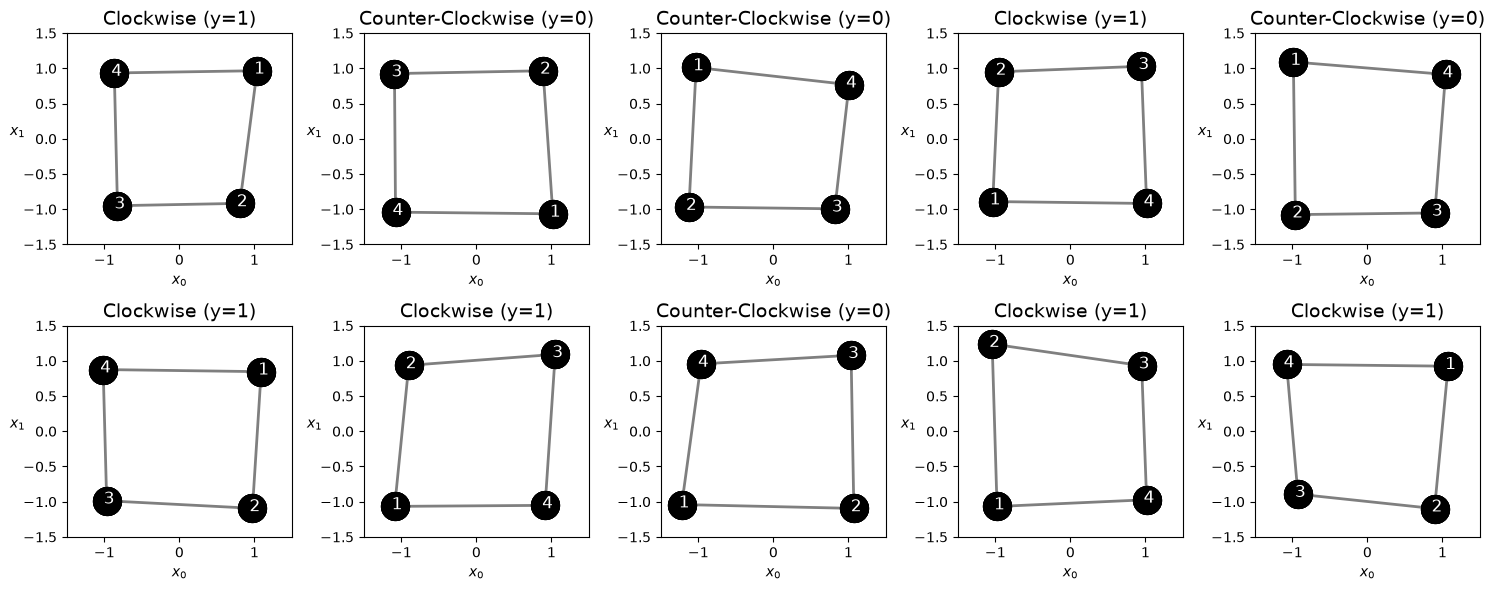

In [41]:
# 程序8-1: 生成数据
points, directions = generate_sequences(n=128, seed=13)

# 128组: 每组4点2维坐标
# 128组: 标签: 1顺时针 0 逆时针
# 1234为组内坐标顺序为绘制顺序
print(np.array(points).shape,np.array(directions).shape)

# 含有噪声的点,标签
print(points[0],directions[0]) 

# 可视化结果
fig = plot_data(points, directions)

> 目前引出了序列是有序的数据这一概念，并以二维图像数据（给两角预测剩余两角为问题）直观的作为问题

----

# 循环神经网络RNN

**Q**:解释术语:
- 隐藏状态

**Q**:回答问题:
- RNN解决的问题是什么？（从隐藏状态的角度出发）
- 作图:RNN的执行流程图是什么样的？
- 文字描述RNN的执行流程（5个步骤）
- 隐藏状态的初始状态代表了什么？
- 最终的隐藏状态代表了什么？


**Q**: 类比:
- 最终的隐藏状态和CNN的卷积块输出有什么异同？
- RNN的单元和CNN比有什么特点？

![](images/rnn2.png)

> RNN的循环意味着反复使用一个单元，上一步的输出状态加上新一步的外部数据就是下一步的输入数据

## RNN单元

**Q**: 回答问题:
- RNN单元的内部结构由什么构成？（数据操作,激活函数）
- RNN处理过程用表达式怎么表示？
- 作图: 神经元层面的RNN单元如何表示？
- 隐藏状态和输入数据在形状上有什么关系？

**Q**: 回答问题
- 为什么要使用特定的激活函数？有什么优势？

**Q**: 结合代码:
- 翻译代码步骤
- 使用`rnn_cell`要注意什么？


![](images/rnn1.png)


![](images/rnn_cell_diagram.png)




In [42]:
# 程序8-2 手动模拟RNN单元的一次计算

# 程序8-2-1: 初始化一个RNN单元(作为参数设置和对比工具)

# 程序8-2-2: 手动复现RNN单元内部的线性层

# 程序8-2-3: 初始化空序列的初始隐藏状态

# 程序8-2-4: 计算隐藏层

# 程序8-2-5: 选一个点计算输入层

# 程序8-2-6: 合并两层结果并使用激活函数

# 程序8-2-7: 测试对比结果（并可视化过程）

In [43]:
# 程序8-2-1: 如何初始化一个RNN单元

# 输入特征的维度（每个时间步的数据有2个特征，即2D坐标点）
n_features = 2
# 隐藏状态的维度（隐藏层神经元数量，设为2便于可视化）
hidden_dim = 2


torch.manual_seed(19)

# RNNCell处理单个时间步
rnn_cell = nn.RNNCell(input_size=n_features, hidden_size=hidden_dim)
rnn_state = rnn_cell.state_dict()
# 打印参数：
# weight_ih: 输入→隐藏层的权重矩阵, 形状(n_features, hidden_dim)的展平 → 实际为(hidden_dim, n_features)
# weight_hh: 隐藏层→隐藏层的权重矩阵, 形状(hidden_dim, hidden_dim)
# bias_ih: 输入→隐藏层的偏置, 形状(hidden_dim,)
# bias_hh: 隐藏层→隐藏层的偏置, 形状(hidden_dim,)
print(rnn_state)

OrderedDict([('weight_ih', tensor([[ 0.6627, -0.4245],
        [ 0.5373,  0.2294]])), ('weight_hh', tensor([[-0.4015, -0.5385],
        [-0.1956, -0.6835]])), ('bias_ih', tensor([0.4954, 0.6533])), ('bias_hh', tensor([-0.3565, -0.2904]))])


In [44]:
# 程序8-2-2: 手动复现RNN单元内部的线性层

# RNNCell内部实际就是: tanh(Linear_input(x) + Linear_hidden(h))


# Linear层：对输入x做线性变换 W_ih @ x + b_ih
linear_input = nn.Linear(n_features, hidden_dim)
# Linear层：对上一时刻隐藏状态h做线性变换 W_hh @ h + b_hh
linear_hidden = nn.Linear(hidden_dim, hidden_dim)

# 在torch.no_grad()上下文中，将RNNCell的参数复制给两个Linear层
# 这样Linear层就和RNNCell具有完全相同的权重
with torch.no_grad():
    # 将RNNCell的输入权重和偏置复制给linear_input
    linear_input.weight = nn.Parameter(rnn_state['weight_ih'])
    linear_input.bias = nn.Parameter(rnn_state['bias_ih'])
    # 将RNNCell的隐藏层权重和偏置复制给linear_hidden
    linear_hidden.weight = nn.Parameter(rnn_state['weight_hh'])
    linear_hidden.bias = nn.Parameter(rnn_state['bias_hh'])

print(linear_input.state_dict())
print(linear_hidden.state_dict())

OrderedDict([('weight', tensor([[ 0.6627, -0.4245],
        [ 0.5373,  0.2294]])), ('bias', tensor([0.4954, 0.6533]))])
OrderedDict([('weight', tensor([[-0.4015, -0.5385],
        [-0.1956, -0.6835]])), ('bias', tensor([-0.3565, -0.2904]))])


In [45]:
# 程序8-2-3: 初始化空序列的初始隐藏状态

initial_hidden = torch.zeros(1, hidden_dim)
print(initial_hidden)

tensor([[0., 0.]])


In [46]:
# 程序8-2-4: 计算隐藏层

th = linear_hidden(initial_hidden)
print(th)

tensor([[-0.3565, -0.2904]], grad_fn=<AddmmBackward0>)


In [47]:
# 程序8-2-5: 选一个点计算输入层
X = torch.as_tensor(points[0]).float()
print(X)

tx = linear_input(X[0:1])
print(tx)

tensor([[ 1.0349,  0.9661],
        [ 0.8055, -0.9169],
        [-0.8251, -0.9499],
        [-0.8670,  0.9342]])
tensor([[0.7712, 1.4310]], grad_fn=<AddmmBackward0>)


In [48]:
# 程序8-2-6: 合并两层结果并使用激活函数

adding = th + tx
print(adding)

# 激活函数: 压缩范围
print(torch.tanh(adding))

tensor([[0.4146, 1.1405]], grad_fn=<AddBackward0>)
tensor([[0.3924, 0.8146]], grad_fn=<TanhBackward0>)


tensor([[0.3924, 0.8146]], grad_fn=<TanhBackward0>)


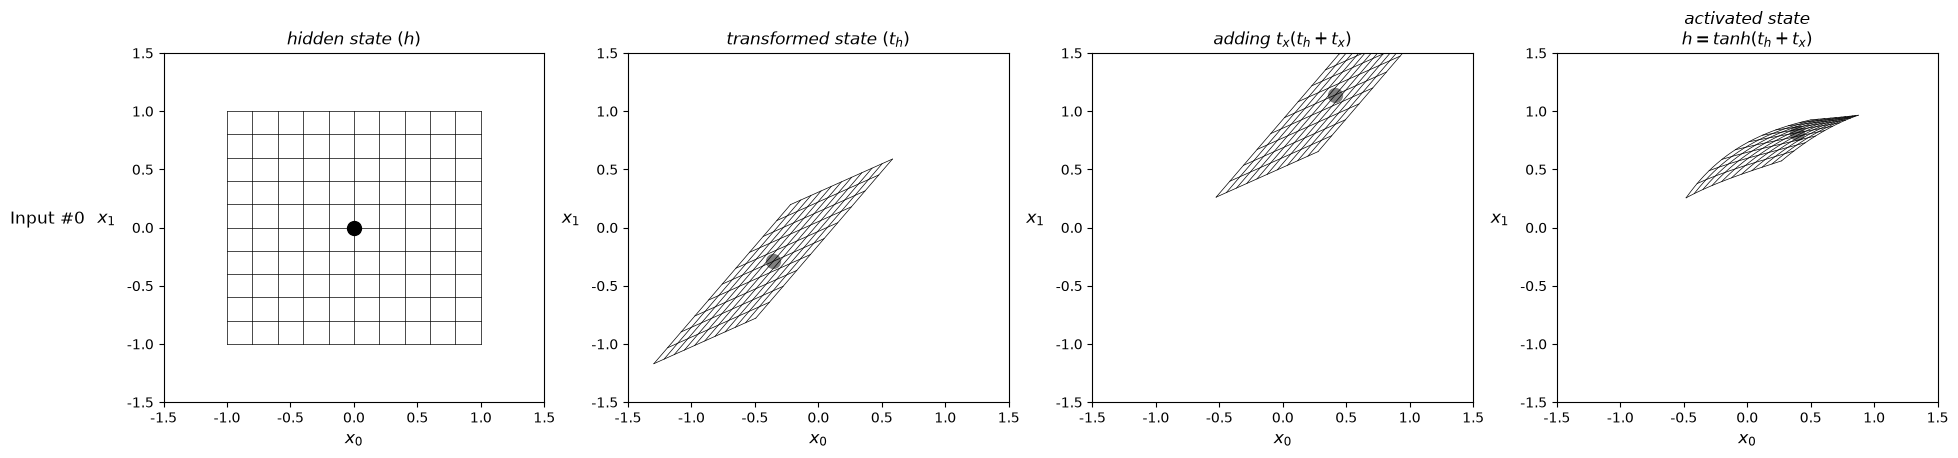

In [49]:
# 程序8-2-7: 测试对比结果并可视化过程

# 直接用RNNCell处理X[0:1]（第1个时间步的坐标点），与前面分步计算的结果对比
print(rnn_cell(X[0:1]))

# figure8函数将RNN单元内部处理过程分解为4个子图进行可视化：
# 子图1: hidden state (h)     — 当前隐藏状态在特征空间中的位置
# 子图2: transformed state    — 隐藏层线性变换结果 W_hh@h + b_hh
# 子图3: adding t_h+t_x       — 隐藏变换与输入变换相加，信息融合
# 子图4: activated state      — tanh激活后的新隐藏状态 h' = tanh(t_h+t_x)
# 注意: 子图1→子图4的变化即RNN对单个时间步的处理过程
fig = figure8(linear_hidden, linear_input, X)

In [50]:
# 程序8-3: rnn_cell的使用注意事项(实现一个序列的RNN)

print(hidden_dim)
print(X.shape[0])

# 这样做只代表4个点的第一步
# ps：不提供状态则默认初始状态
print(rnn_cell(X))

# 这才是从1-4的4步RNN
hidden = torch.zeros(1, hidden_dim)
for i in range(X.shape[0]):
    out = rnn_cell(X[i:i+1], hidden)
    print(out)
    hidden = out

2
4
tensor([[ 0.3924,  0.8146],
        [ 0.7864,  0.5266],
        [-0.0047, -0.2897],
        [-0.6817,  0.1109]], grad_fn=<TanhBackward0>)
tensor([[0.3924, 0.8146]], grad_fn=<TanhBackward0>)
tensor([[ 0.4347, -0.0481]], grad_fn=<TanhBackward0>)
tensor([[-0.1521, -0.3367]], grad_fn=<TanhBackward0>)
tensor([[-0.5297,  0.3551]], grad_fn=<TanhBackward0>)


> 上述循环可用下图表示

![](images/rnn_cell_diagram_seq.png)

> RNN单元的内部是由两个线性层求和+一个Tanh激活函数组成，线性层计算的分别是本次的输入数据和隐藏状态

>`RNNCell`是RNN单元的抽象类，需要两个输入，即数据和隐藏状态

---

## RNN层

**Q**: 解释RNN的参数意义
- input_size
- hidden_size
- bias
- nolinearity

**Q**: 解释RNN的参数意义2
- num_layers
- bidirectional
- dropout
- batch_first

**Q**:一句话回答问题
- 堆叠RNN是什么？
- 双向RNN是什么

**Q**:结合代码结果
- `state_dict`返回的参数名称的后缀代表什么？

In [51]:
# 程序8-4: RNN层的使用

n_features = 2
hidden_dim = 2

torch.manual_seed(19)
rnn = nn.RNN(input_size=n_features, hidden_size=hidden_dim)

# 注意和自定义的RNNCell初始化的结果是一样的
print(rnn.state_dict())

OrderedDict([('weight_ih_l0', tensor([[ 0.6627, -0.4245],
        [ 0.5373,  0.2294]])), ('weight_hh_l0', tensor([[-0.4015, -0.5385],
        [-0.1956, -0.6835]])), ('bias_ih_l0', tensor([0.4954, 0.6533])), ('bias_hh_l0', tensor([-0.3565, -0.2904]))])


> RNN层封装了RNNCell的计算循环，除了提供基本的输入size和隐藏层size还可指定激活函数和RNN的内部层(堆叠和双向),另外还可在堆叠中加dropout和规定序列的形状
---

## 形状

暂未明确解释的术语:
- 打包序列

**Q**: 回答问题
- RNN需要的输入输出张量形状是什么?(非batch_first下)
- RNN需要的输入输出张量形状是什么?(batch_first下)
- 初始隐藏状态默认是什么?
- 隐藏状态的形状是什么？进一步堆叠和双向形状分别是什么？
- 输出张量形状是什么?(batch_first下和非batch_first下)(堆叠和双向下)？

**Q**: 结合代码
- `permute`的作用？

In [52]:
# 程序8-5 研究RNN层输入和输出的形状

# 程序8-5-1: 生成数据的形状

# 程序8-5-2: permute的使用: 交换分量

# 程序8-5-3: RNN层计算和其特点

# 程序8-5-4: 手动隐藏层转为batch_first

# 程序8-5-5: 注意batch_first影响的对象

In [53]:
# 程序8-5-1: 生成数据的结构

# points(128, 4, 2) direction(128,)
batch = torch.as_tensor(points[:3]).float()

# (N L F)batch_first格式: 批量大小 序列长度 特征数量
print(batch.shape)

torch.Size([3, 4, 2])


In [54]:
# 程序8-5-2: permute的使用: 交换分量
permuted_batch = batch.permute(1, 0, 2)

# RNN友好格式(序列优先): L N F
print(permuted_batch.shape)

torch.Size([4, 3, 2])


In [55]:
# 程序8-5-3: RNN层计算和其特点

torch.manual_seed(19)
rnn = nn.RNN(input_size=n_features, hidden_size=hidden_dim)
out, final_hidden = rnn(permuted_batch)

# 结果也是序列优先
print(out.shape, final_hidden.shape)

# 最后输出即是最终隐藏层
print((out[-1] == final_hidden).all())

torch.Size([4, 3, 2]) torch.Size([1, 3, 2])
tensor(True)


In [56]:
# 程序8-5-4: 手动隐藏层转为batch_first

batch_hidden = final_hidden.permute(1, 0, 2)
print(batch_hidden.shape)

torch.Size([3, 1, 2])


In [57]:
# 程序8-5-5: 注意batch_first影响的对象

torch.manual_seed(19)
rnn_batch_first = nn.RNN(input_size=n_features, hidden_size=hidden_dim, batch_first=True)
out, final_hidden = rnn_batch_first(batch)
print(out.shape, final_hidden.shape)

torch.Size([3, 4, 2]) torch.Size([1, 3, 2])


> RNN友好格式LNF,隐藏格式1NH,1受双向和堆叠影响2*堆叠层或对叠层数，输出LNH,H受受双向和堆叠影响2H和H,batch_first不影响最终隐藏层状态shape

> RNN最终状态应该和最后输出的最后一个元素相同
---